# Email Spam Detection with Machine Learning

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load Dataset

In [2]:
df = pd.read_csv("spam.csv", encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


### 3. Dataset Information

In [3]:
df.shape

(5572, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


### 4. Data Cleaning

In [5]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace=True)

df.rename(columns={
    'v1':'Category',
    'v2':'Message'
}, inplace=True)

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df.isnull().sum()

,0
Category,0
Message,0


In [8]:
df.duplicated().sum()

np.int64(403)

In [9]:
df = df.drop_duplicates()

df.shape

(5169, 2)

### Observation:

Unnecessary columns were removed and column names were renamed for better readability. Duplicate records were removed to improve data quality and model performance.

### 5. Label Encoding

In [10]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Category'] = encoder.fit_transform(df['Category'])

df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


### Observation:

The Category column was converted into numerical format. Ham messages are represented as 0 and Spam messages as 1.

### 6. Exploratory Data Analysis (EDA)

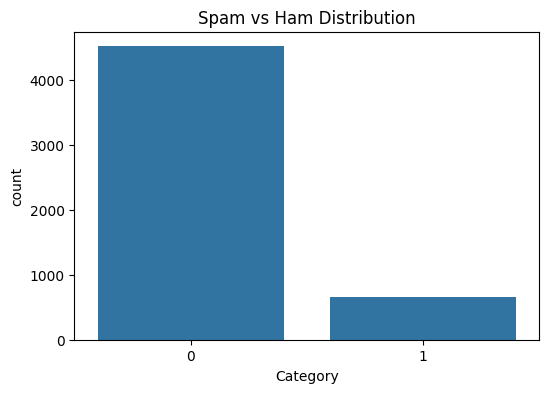

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x=df['Category'])

plt.title("Spam vs Ham Distribution")

plt.show()

### Observation:

The distribution plot shows the number of spam and non-spam messages present in the dataset.

### 7. Text Preprocessing

In [12]:
df['Message_Length'] = df['Message'].apply(len)

df.head()

,Category,Message,Message_Length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


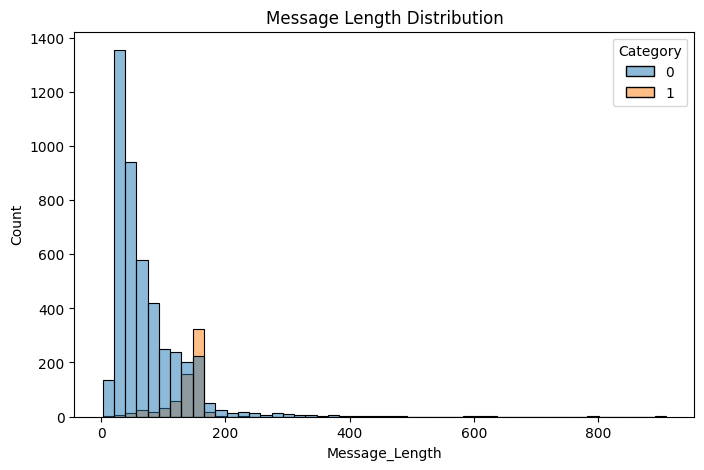

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Message_Length',
    hue='Category',
    bins=50
)

plt.title("Message Length Distribution")

plt.show()

### Observation:

Spam messages generally tend to be longer than normal messages. Message length can be a useful feature for spam detection.

### 8. Text Vectorization

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=3000
)

X = tfidf.fit_transform(df['Message']).toarray()

y = df['Category']

### Observation:

TF-IDF Vectorization converts text messages into numerical feature vectors that can be understood by machine learning algorithms.

### 9. Train-Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4135, 3000)
(1034, 3000)


### Observation:

The dataset was divided into training and testing sets. The training set is used for learning, while the testing set is used for evaluation.

### 10. Model Training

In [16]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### Observation:

The Multinomial Naive Bayes algorithm was selected because it performs very well on text classification tasks such as spam detection.

### 11. Model Evaluation

In [17]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.9758220502901354
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       889
           1       0.99      0.83      0.91       145

    accuracy                           0.98      1034
   macro avg       0.98      0.92      0.95      1034
weighted avg       0.98      0.98      0.97      1034



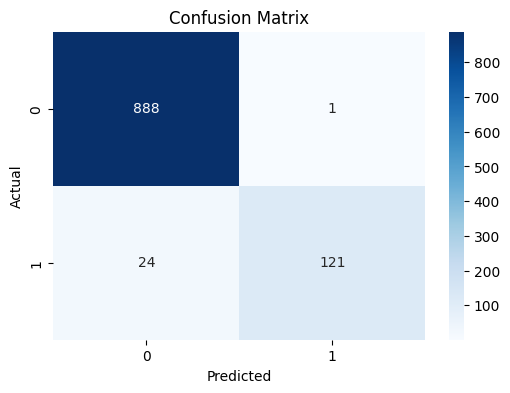

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation:

The confusion matrix shows how many messages were correctly classified as spam or ham. A higher number of correct predictions indicates better model performance.Observation:

The model achieved an accuracy of 97.58%, correctly classifying most spam and ham messages. Only a small number of spam messages were misclassified, indicating strong performance of the spam detection system.

# **Conclusion**

In this project, an Email Spam Detection system was developed using Machine Learning. The dataset was cleaned and preprocessed before applying TF-IDF vectorization to convert text messages into numerical features. A Multinomial Naive Bayes classifier was trained to classify messages as spam or ham. The model achieved an accuracy of approximately 97.58%, demonstrating excellent performance in detecting spam messages. This project highlights the effectiveness of Natural Language Processing and Machine Learning techniques for text classification tasks.